In [1]:
import matplotlib
import mlx.core as mx
import matplotlib.pyplot as plt

print("Hello, World!")
print("MLX version:", mx.__version__)
print("Matplotlib version:", matplotlib.__version__)


Hello, World!
MLX version: 0.30.3
Matplotlib version: 3.10.0


In [2]:

sizes = [784, 16, 16, 10]
print(sizes[:-1])
print(sizes[1:])
print(list(zip(sizes[:-1], sizes[1:])))


[784, 16, 16]
[16, 16, 10]
[(784, 16), (16, 16), (16, 10)]


In [3]:
def sigmoid(z):
    return 1 / (1 + mx.exp(-z))

def sigmoid_prime(z):
    """Derivative of the sigmoid function."""
    s = sigmoid(z)
    return s * (1 - s)

In [4]:
class NeuralNetwork(object):
    def __init__(self, sizes):
        """The list ``sizes`` contains the number of neurons in the
        respective layers of the network.  For example, if the list
        was [2, 3, 1] then it would be a three-layer network, with the
        first layer containing 2 neurons, the second layer 3 neurons,
        and the third layer 1 neuron.  The biases and weights for the
        network are initialized randomly, using a Gaussian
        distribution with mean 0, and variance 1.  Note that the first
        layer is assumed to be an input layer, and by convention we
        won't set any biases for those neurons, since biases are only
        ever used in computing the outputs from later layers."""
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.biases  = [mx.random.normal(shape=(y, 1)) for y in sizes[1:]]
        self.weights = [mx.random.normal(shape=(y, x))
                        for x, y in zip(sizes[:-1], sizes[1:])]
        mx.eval(self.weights, self.biases)

    def feed_forward(self, a):
        """Forward pass. a can be (in_size, 1) or (in_size, batch_size)."""
        for b, w in zip(self.biases, self.weights):
            a = sigmoid(mx.matmul(w, a) + b)
        return a

    def SGD(self, X_train, Y_train, epochs, mini_batch_size, learning_rate,
            test_data=None):
        """Train via mini-batch stochastic gradient descent.

        Args:
            X_train:   (784, N) MLX array of training images
            Y_train:   (10,  N) MLX array of one-hot labels
            test_data: optional (X_test, Y_labels) tuple
                       X_test   -- (784, M) MLX array
                       Y_labels -- (M,) MLX int32 array of digit indices
        """
        n = X_train.shape[1]
        n_test = test_data[1].shape[0] if test_data is not None else None
        accuracies = []
        for j in range(epochs):
            # Shuffle columns with an MLX random permutation
            idx = mx.argsort(mx.random.uniform(shape=(n,)))
            X_s = X_train[:, idx]
            Y_s = Y_train[:, idx]
            for k in range(0, n, mini_batch_size):
                self.update_mini_batch(
                    X_s[:, k:k + mini_batch_size],
                    Y_s[:, k:k + mini_batch_size],
                    learning_rate)
            if test_data is not None:
                metric = self.evaluate(*test_data)
                accuracies.append(metric)
                print(f"Epoch {j}: {metric} / {n_test}")
            else:
                print(f"Epoch {j} complete")
        return accuracies

    def update_mini_batch(self, X, Y, learning_rate):
        """Update weights & biases from one mini-batch.

        Args:
            X: (784, B) MLX array
            Y: (10,  B) MLX array one-hot labels
        """
        nabla_b, nabla_w = self.back_prop_batch(X, Y)
        lr = learning_rate / X.shape[1]
        self.weights = [w - lr * nw for w, nw in zip(self.weights, nabla_w)]
        self.biases  = [b - lr * nb for b, nb in zip(self.biases,  nabla_b)]
        # Flush the lazy compute graph so Metal can reclaim memory
        mx.eval(self.weights, self.biases)

    def back_prop_batch(self, X, Y):
        """Vectorised backprop over a full mini-batch.

        Args:
            X: (784, B) input batch
            Y: (10,  B) one-hot target batch
        Returns:
            nabla_b: list of (out, 1)   bias-gradient arrays  (summed over batch)
            nabla_w: list of (out, in)  weight-gradient arrays (summed over batch)
        """
        # ---- forward pass ----
        activation = X
        activations = [X]
        zs = []
        for b, w in zip(self.biases, self.weights):
            z = mx.matmul(w, activation) + b   # b (out,1) broadcasts over B
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)

        # ---- backward pass ----
        nabla_b = [None] * (self.num_layers - 1)
        nabla_w = [None] * (self.num_layers - 1)

        delta = self.cost_derivative(activations[-1], Y) * sigmoid_prime(zs[-1])
        nabla_b[-1] = mx.sum(delta, axis=1, keepdims=True)   # sum over batch dim
        nabla_w[-1] = mx.matmul(delta, mx.transpose(activations[-2]))

        for l in range(2, self.num_layers):
            sp    = sigmoid_prime(zs[-l])
            delta = mx.matmul(mx.transpose(self.weights[-l + 1]), delta) * sp
            nabla_b[-l] = mx.sum(delta, axis=1, keepdims=True)
            nabla_w[-l] = mx.matmul(delta, mx.transpose(activations[-l - 1]))

        return nabla_b, nabla_w

    def evaluate(self, X_test, Y_labels):
        """Return number of correctly classified samples.

        Args:
            X_test:   (784, M) MLX array
            Y_labels: (M,)     MLX int32 digit-index array
        """
        preds = mx.argmax(self.feed_forward(X_test), axis=0)   # (M,)
        return int(mx.sum(preds == Y_labels))

    def cost_derivative(self, output_activations, y):
        return output_activations - y


In [7]:
import importlib, mnist_loader
importlib.reload(mnist_loader)

(X_train, Y_train), (X_val, Y_val), (X_test, Y_test) = mnist_loader.load_data_mlx()

print("Training:  ", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape,   Y_val.shape)
print("Test:      ", X_test.shape,  Y_test.shape)

nn = NeuralNetwork([784, 16, 16, 10])


Training:   (784, 50000) (10, 50000)
Validation: (784, 10000) (10000,)
Test:       (784, 10000) (10000,)


Epoch 0: 8294 / 10000
Epoch 1: 8866 / 10000
Epoch 2: 9004 / 10000
Epoch 3: 9108 / 10000
Epoch 4: 9113 / 10000
Epoch 5: 9140 / 10000
Epoch 6: 9210 / 10000
Epoch 7: 9206 / 10000
Epoch 8: 9232 / 10000
Epoch 9: 9239 / 10000
Epoch 10: 9245 / 10000
Epoch 11: 9261 / 10000
Epoch 12: 9246 / 10000
Epoch 13: 9258 / 10000
Epoch 14: 9288 / 10000
Epoch 15: 9244 / 10000
Epoch 16: 9247 / 10000
Epoch 17: 9260 / 10000
Epoch 18: 9260 / 10000
Epoch 19: 9270 / 10000
Epoch 20: 9300 / 10000
Epoch 21: 9290 / 10000
Epoch 22: 9279 / 10000
Epoch 23: 9325 / 10000
Epoch 24: 9269 / 10000
Epoch 25: 9283 / 10000
Epoch 26: 9294 / 10000
Epoch 27: 9307 / 10000
Epoch 28: 9316 / 10000
Epoch 29: 9291 / 10000
Epoch 30: 9299 / 10000
Epoch 31: 9309 / 10000
Epoch 32: 9313 / 10000
Epoch 33: 9314 / 10000
Epoch 34: 9298 / 10000
Epoch 35: 9325 / 10000
Epoch 36: 9324 / 10000
Epoch 37: 9312 / 10000
Epoch 38: 9311 / 10000
Epoch 39: 9325 / 10000
Epoch 40: 9306 / 10000
Epoch 41: 9322 / 10000
Epoch 42: 9290 / 10000
Epoch 43: 9315 / 1000

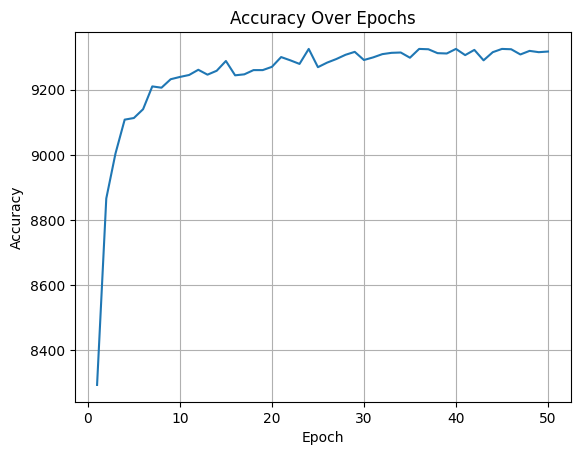

In [8]:
# Train the network using Stochastic Gradient Descent
accuracies = nn.SGD(X_train, Y_train, epochs=50, mini_batch_size=32,
                    learning_rate=3.0, test_data=(X_test, Y_test))
plt.plot(range(1, len(accuracies)+1), accuracies)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.grid()
plt.show()


In [9]:
first_input = X_train[:, :1]      # (784, 1)
first_label = Y_train[:, 0]       # (10,)  one-hot

prediction = nn.feed_forward(first_input)   # (10, 1)
pred_digit = int(mx.argmax(prediction))
true_digit = int(mx.argmax(first_label))
cost = float(mx.sqrt(mx.sum((prediction.reshape(-1) - first_label) ** 2)))

print("Predicted vector:", prediction.reshape(-1).tolist())
print("True label vector:", first_label.tolist())
print(f"Predicted digit: {pred_digit}")
print(f"True digit: {true_digit}")
print(f"Cost: {cost:.4f}")


Predicted vector: [1.3166247754270444e-06, 3.4849242069867614e-07, 5.589978968600917e-07, 0.9998527765274048, 7.764629827988756e-09, 0.00369447935372591, 6.393351270617131e-08, 1.8525934137869626e-05, 8.079349100853506e-08, 0.00012358474486973137]
True label vector: [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Predicted digit: 3
True digit: 3
Cost: 0.0037
